# EXPERIMENT 4

---


## Hill Climbing Search using Python

---

<br>

**Name:** Sakshi Bhatt<br>
**SAP ID:** 500121811 <br>
**Roll No:** R2142230740<br>
**Batch:** B8<br>
**Course:** Algorithms for Intelligent Systems and Robotics Lab

---
**Submitted To**- Dr. Neetu Singh



## AIM

---


To implement the hill climbing algorithm in Python, use it for maximising a function, observe the local maxima problem, improve it using random restart, and apply the same method for a robot moving towards a goal on a grid map.


## THEORY

---


Hill climbing is a heuristic based local search. Unlike BFS or DFS it does not store the frontier, it keeps only the current state in memory. At each step the neighbours of the current state are generated, and the algorithm moves to a neighbour which has a better value of the objective function.
<br>


### TYPES

---


- **Simple hill climbing:** moves to the first neighbour which is better.
- **Steepest ascent hill climbing:** checks all the neighbours and moves to the best one.
- **Stochastic hill climbing:** picks a better neighbour randomly.
<br>

### DRAWBACKS

---


- **Local maximum:** the algorithm stops at a peak which is not the highest one.
- **Plateau:** all neighbours have the same value so there is no direction to move.
- **Ridge:** the slope is upward in a direction which is not available in the move set.


## 1. A function with a single peak
$f(x)=10-(x-2)^2$, the maximum is at $x=2$.


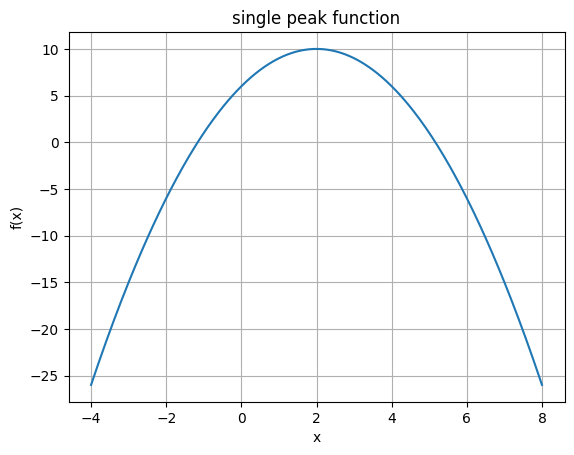

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 10 - (x - 2)**2

xs = np.linspace(-4, 8, 300)
plt.plot(xs, f(xs))
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("single peak function")
plt.grid(True)
plt.show()


## 2. Simple hill climbing
The first neighbour which gives a better value is accepted, the other one is not checked.


In [2]:
def simple_hill_climb(f, x, step=0.1, max_iter=500):
    path = [x]
    for i in range(max_iter):
        moved = False
        for nb in [x - step, x + step]:
            if f(nb) > f(x):
                x = nb
                path.append(x)
                moved = True
                break
        if not moved:
            break
    return x, path

peak, path = simple_hill_climb(f, -3.0)
print("start = -3.0")
print("peak at x =", round(peak,3), " value =", round(f(peak),3))
print("moves taken =", len(path)-1)


start = -3.0
peak at x = 2.0  value = 10.0
moves taken = 50


## 3. Steepest ascent hill climbing
Here we will check both the neighbours and the better one is taken.


peak at x = 2.0  moves = 50


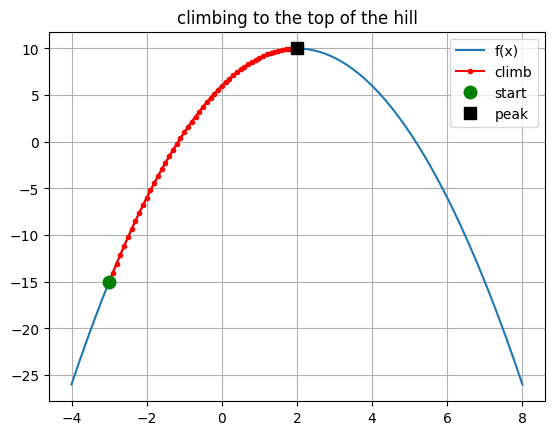

In [3]:
def steepest_ascent(f, x, step=0.1, max_iter=500):
    path = [x]
    for i in range(max_iter):
        best = max([x - step, x + step], key=f)
        if f(best) <= f(x):
            break
        x = best
        path.append(x)
    return x, path

peak2, path2 = steepest_ascent(f, -3.0)
print("peak at x =", round(peak2,3), " moves =", len(path2)-1)

plt.plot(xs, f(xs), label="f(x)")
plt.plot(path2, [f(v) for v in path2], 'r.-', label="climb")
plt.plot(path2[0], f(path2[0]), 'go', markersize=9, label="start")
plt.plot(path2[-1], f(path2[-1]), 'ks', markersize=8, label="peak")
plt.legend(); plt.grid(True)
plt.title("climbing to the top of the hill")
plt.show()


## 4. Local maxima problem
Now taking $f(x)=x\sin(x)$ between 0 and 15. This function has many peaks and the peaks keep getting bigger, so where the search stops fully depends on the starting point.


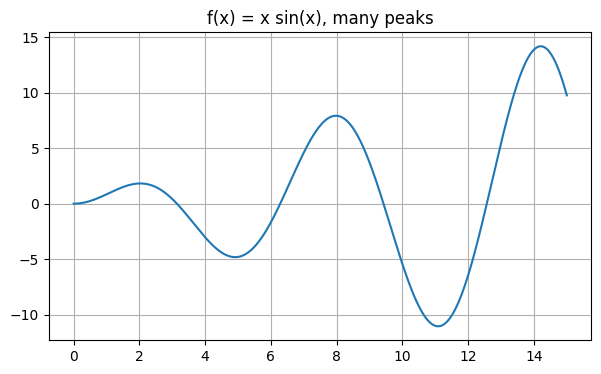

global maximum is near x = 14.21  value = 14.172
start 1.0  stopped at x = 2.05  value = 1.819
start 5.0  stopped at x = 8.0  value = 7.915
start 9.0  stopped at x = 8.0  value = 7.915
start 13.0  stopped at x = 14.2  value = 14.172


In [4]:
def g(x):
    return x * np.sin(x)

xg = np.linspace(0, 15, 800)
plt.figure(figsize=(7,4))
plt.plot(xg, g(xg))
plt.title("f(x) = x sin(x), many peaks")
plt.grid(True)
plt.show()

print("global maximum is near x =", round(xg[g(xg).argmax()],2), " value =", round(g(xg).max(),3))

for s in [1.0, 5.0, 9.0, 13.0]:
    p, _ = steepest_ascent(g, s, step=0.05)
    print("start", s, " stopped at x =", round(p,3), " value =", round(g(p),3))


###Observation: <br>

---


Only the start at 13.0 reached the real answer. The other three stopped on smaller peaks because the neighbours on both sides were lower.

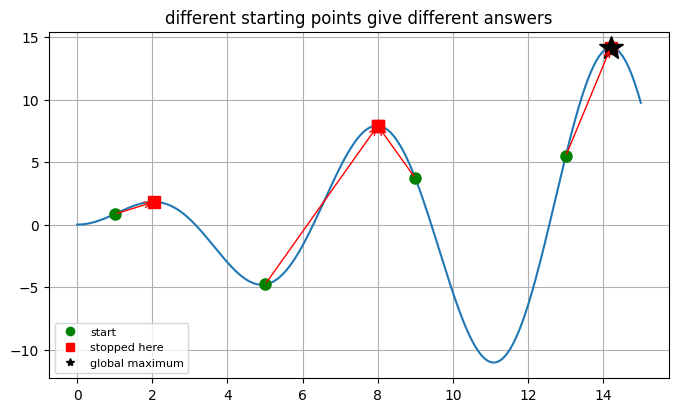

In [5]:
plt.figure(figsize=(8,4.5))
plt.plot(xg, g(xg))
for s in [1.0, 5.0, 9.0, 13.0]:
    stop, _ = steepest_ascent(g, s, step=0.05)
    plt.plot(s, g(s), 'go', markersize=8)
    plt.plot(stop, g(stop), 'rs', markersize=9)
    plt.annotate("", xy=(stop, g(stop)), xytext=(s, g(s)),
                 arrowprops=dict(arrowstyle="->", color='red'))
gx = xg[g(xg).argmax()]
plt.plot(gx, g(gx), 'k*', markersize=18)
plt.plot([], [], 'go', label="start")
plt.plot([], [], 'rs', label="stopped here")
plt.plot([], [], 'k*', label="global maximum")
plt.legend(loc='lower left', fontsize=8)
plt.title("different starting points give different answers")
plt.grid(True)
plt.show()


## 5. Random restart hill climbing
The climbing is repeated from random starting points and the best result out of all of them is kept.


In [6]:
import random
random.seed(2)

def random_restart(f, low, high, tries=10, step=0.05):
    best_x = None
    peaks = []
    for i in range(tries):
        s = random.uniform(low, high)
        x, _ = steepest_ascent(f, s, step=step)
        peaks.append([s, x])
        print("try", i, ": start", round(s,2), " peak", round(x,3), " value", round(f(x),3))
        if best_x is None or f(x) > f(best_x):
            best_x = x
    return best_x, peaks

best, peaks = random_restart(g, 0, 15, tries=8)
print()
print("best answer : x =", round(best,3), " value =", round(g(best),3))


try 0 : start 14.34  peak 14.191  value 14.17
try 1 : start 14.22  peak 14.217  value 14.172
try 2 : start 0.85  peak 2.048  value 1.819
try 3 : start 1.27  peak 2.023  value 1.82
try 4 : start 12.53  peak 14.182  value 14.168
try 5 : start 11.04  peak 7.99  value 7.916
try 6 : start 10.05  peak 7.996  value 7.916
try 7 : start 4.62  peak 2.022  value 1.82

best answer : x = 14.217  value = 14.172


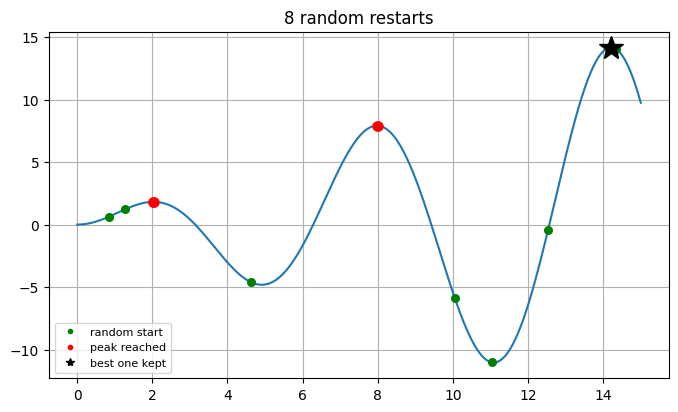

In [7]:
plt.figure(figsize=(8,4.5))
plt.plot(xg, g(xg))
for s, x in peaks:
    plt.plot(s, g(s), 'g.', markersize=11)
    plt.plot(x, g(x), 'r.', markersize=13)
plt.plot(best, g(best), 'k*', markersize=18)
plt.plot([], [], 'g.', label="random start")
plt.plot([], [], 'r.', label="peak reached")
plt.plot([], [], 'k*', label="best one kept")
plt.legend(loc='lower left', fontsize=8)
plt.title("8 random restarts")
plt.grid(True)
plt.show()


## 6. How many restarts are actually needed
Running 50 restarts and counting how many of them reached the global maximum, this gives the success rate of one single run.


In [8]:
random.seed(7)
true_max = g(xg).max()
success = 0
runs = 50
for i in range(runs):
    s = random.uniform(0, 15)
    x, _ = steepest_ascent(g, s, step=0.05)
    if abs(g(x) - true_max) < 0.01:
        success = success + 1
print("out of", runs, "runs the global maximum was found", success, "times")
print("success rate of one run =", round(success/runs*100, 1), "%")


out of 50 runs the global maximum was found 7 times
success rate of one run = 14.0 %


## 7. Hill climbing for a robot on a grid
The state is the cell where the robot is standing, the neighbours are the free cells around it and the heuristic is the Manhattan distance to the goal.
<br>

**Here we want to reduce the distance so the better neighbour is the one with the smaller value.**

The obstacle is kept in a C shape whose opening is facing the robot, this is the worst case for this algorithm.


In [9]:
grid = np.zeros((8,8), dtype=int)
grid[1, 3:6] = 1  # top of the C
grid[5, 3:6] = 1  # bottom of the C
grid[1:6, 5] = 1  # closed side of the C
start = (3, 0)
goal = (3, 7)
print(grid)

def h(cell):
    return abs(cell[0]-goal[0]) + abs(cell[1]-goal[1])

def moves(grid, cell):
    rows, cols = grid.shape
    r, c = cell
    out = []
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            out.append((nr, nc))
    return out

print("h at start =", h(start))


[[0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
h at start = 7


In [10]:
def hill_climb_robot(grid, start, goal):
    cur = start
    path = [cur]
    while cur != goal:
        nbs = moves(grid, cur)
        best = min(nbs, key=h)
        if h(best) >= h(cur):
            return path, False
        cur = best
        path.append(cur)
    return path, True

robot_path, reached = hill_climb_robot(grid, start, goal)
print("path :", robot_path)
print("goal reached :", reached)
print("stopped at", robot_path[-1], "with h =", h(robot_path[-1]))


path : [(3, 0), (3, 1), (3, 2), (3, 3), (3, 4)]
goal reached : False
stopped at (3, 4) with h = 3


The robot walked straight inside the C and stopped at (3,4). Every free neighbour from there has distance 4 which is worse than the current 3, so no move looks good and the search ends. This is the local minimum of the heuristic.


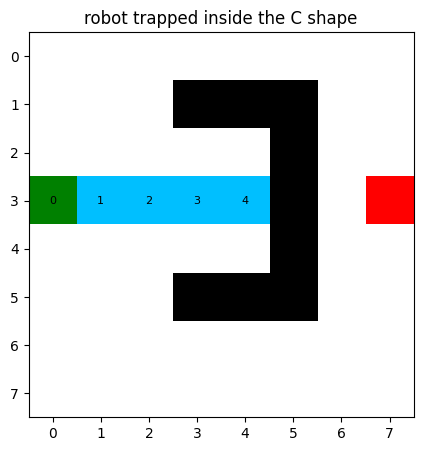

In [11]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'black', 'deepskyblue', 'green', 'red'])
img = grid.copy()
for cell in robot_path:
    img[cell] = 2
img[start] = 3
img[goal] = 4
plt.figure(figsize=(5,5))
plt.imshow(img, cmap=cmap, vmin=0, vmax=4)
for i, cell in enumerate(robot_path):
    plt.text(cell[1], cell[0], str(i), ha='center', va='center', fontsize=8)
plt.title("robot trapped inside the C shape")
plt.xticks(range(8)); plt.yticks(range(8))
plt.show()


BFS on the same map does reach the goal, because it does not follow any heuristic and expands in all the directions.


In [12]:
from collections import deque

def bfs_path(grid, start, goal):
    q = deque([[start]])
    seen = {start}
    while q:
        path = q.popleft()
        if path[-1] == goal:
            return path
        for m in moves(grid, path[-1]):
            if m not in seen:
                seen.add(m)
                q.append(path + [m])
    return None

bp = bfs_path(grid, start, goal)
print("BFS reached the goal in", len(bp)-1, "steps")


BFS reached the goal in 13 steps


## 8. RESULT


---


| Property | Hill climbing | BFS |
|---|---|---|
| States stored | Only the current one | Whole frontier |
| Memory | Very less | High |
| Heuristic used | Yes | No |
| Optimal | Not always | Yes for unweighted graph |
| Can get stuck | Local maxima, plateau, ridge | No |

### OBSERVATIONS:

---


1. On the single peak function the algorithm reached the maximum from any starting point.
2. On $f(x)=x\sin(x)$ it stopped at a local maximum for 3 out of the 4 starting points.
3. Random restart with 8 tries reached the global maximum.
4. On the grid map the robot entered the C shaped obstacle and stopped at (3,4) even though a path to the goal was present, and BFS found that path.


## 9. CONCLUSION

---


The hill climbing algorithm was implemented and studied on a continuous function as well as on a discrete grid environment.

The method is simple and it uses a very small amount of memory because only the current state is kept, and on a function having a single peak it reaches the optimum from any starting point.

At the same time the experiment shows the main weakness of the method. Since a move is accepted only when an immediate neighbour is better, the search stops as soon as it reaches a point where all the neighbours are worse, without any information about whether a better solution exists somewhere else.


---


It is concluded that hill climbing is suitable where memory and speed matter more than the quality of the solution, while for robot path planning among obstacles an informed search such as A*, which uses the actual cost along with the heuristic, is necessary.
